# Supplementary Figures for Manuscript

This notebook generates all supplementary figures (Figure S1-S7) for the manuscript.

In [1]:
import sys
sys.path.insert(0, '../shared')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

from plot_config import (
    COLORS, TRANSITION_ORDER, TRANSITION_PALETTE,
    set_nature_style, despine, add_significance_stars
)

set_nature_style()

# Paths
data_path = Path('..')
fig_path = Path('../manuscript/figures')
fig_path.mkdir(exist_ok=True)

print('Colors:', COLORS)

Colors: {'high': '#E64B35', 'low': '#4DBBD5', 'HH': '#E64B35', 'HL': '#F39B7F', 'LH': '#7E6148', 'LL': '#4DBBD5', 'same': '#3C5488', 'switch': '#F39B7F', 'exp1': '#00A087', 'exp2': '#8491B4', 'neutral': '#666666'}


## Load Data and Construct N-back Variables BEFORE Removing Outliers

In [2]:
# Load raw data - n-back columns already exist from data preprocessing (1_Data_QC.ipynb)
# The n-back columns were computed BEFORE outlier flagging in the original pipeline
df1_raw = pd.read_pickle(data_path / 'Experiment1/Analysis/E1.pkl')
df2_raw = pd.read_pickle(data_path / 'Experiment2/Analysis/E2.pkl')

# Check which n-back columns exist
nback_cols_1 = [c for c in df1_raw.columns if c.startswith('preDur') and 'back' in c]
nback_cols_2 = [c for c in df2_raw.columns if c.startswith('preDur') and 'back' in c]
print(f'Exp1 n-back columns: {sorted(nback_cols_1)}')
print(f'Exp2 n-back columns: {sorted(nback_cols_2)}')

# Add any missing n-back columns using groupby().shift() - preserves row order
def ensure_nback_columns(df, max_back=10):
    """Ensure n-back duration columns exist (computed BEFORE outlier removal)."""
    df = df.copy()
    for n in range(1, max_back + 1):
        col = f'preDur{n}back'
        if col not in df.columns:
            df[col] = df.groupby('subID')['curDur'].shift(n)
    return df

df1_raw = ensure_nback_columns(df1_raw)
df2_raw = ensure_nback_columns(df2_raw)

# Remove outliers AFTER n-back columns are set
df1 = df1_raw[df1_raw['is_outlier'] == False].copy()
df2 = df2_raw[df2_raw['is_outlier'] == False].copy()

print(f'Exp1: {len(df1)} trials, {df1.subID.nunique()} subjects')
print(f'Exp2: {len(df2)} trials, {df2.subID.nunique()} subjects')

Exp1 n-back columns: ['preDur10back', 'preDur1back', 'preDur1backc', 'preDur2back', 'preDur3back', 'preDur4back', 'preDur5back', 'preDur6back', 'preDur7back', 'preDur8back', 'preDur9back']
Exp2 n-back columns: ['preDur10back', 'preDur1back', 'preDur1backc', 'preDur2back', 'preDur3back', 'preDur4back', 'preDur5back', 'preDur6back', 'preDur7back', 'preDur8back', 'preDur9back']
Exp1: 4659 trials, 22 subjects
Exp2: 4677 trials, 22 subjects


## Helper Functions

In [3]:
def compute_cti(df):
    """Compute Central Tendency Index per subject and condition."""
    results = []
    for sub in df['subID'].unique():
        for tt in df['TransitionType'].unique():
            sub_df = df[(df['subID'] == sub) & (df['TransitionType'] == tt)]
            if len(sub_df) > 5:
                slope, intercept, _, _, _ = stats.linregress(sub_df['curDur'], sub_df['curBias'])
                results.append({
                    'subID': sub,
                    'TransitionType': tt,
                    'CTI': abs(slope),
                    'Intercept': intercept
                })
    return pd.DataFrame(results)

def compute_sdi(df):
    """Compute Serial Dependence Index per subject and condition."""
    results = []
    for sub in df['subID'].unique():
        for tt in df['TransitionType'].unique():
            sub_df = df[(df['subID'] == sub) & (df['TransitionType'] == tt)]
            if len(sub_df) > 5 and 'preDur1back' in sub_df.columns:
                valid = sub_df.dropna(subset=['preDur1back', 'curBias'])
                if len(valid) > 5:
                    slope, intercept, _, _, _ = stats.linregress(valid['preDur1back'], valid['curBias'])
                    results.append({
                        'subID': sub,
                        'TransitionType': tt,
                        'SDI': slope,
                        'Intercept': intercept
                    })
    return pd.DataFrame(results)

## Figure S1: Central Tendency - Experiment 1

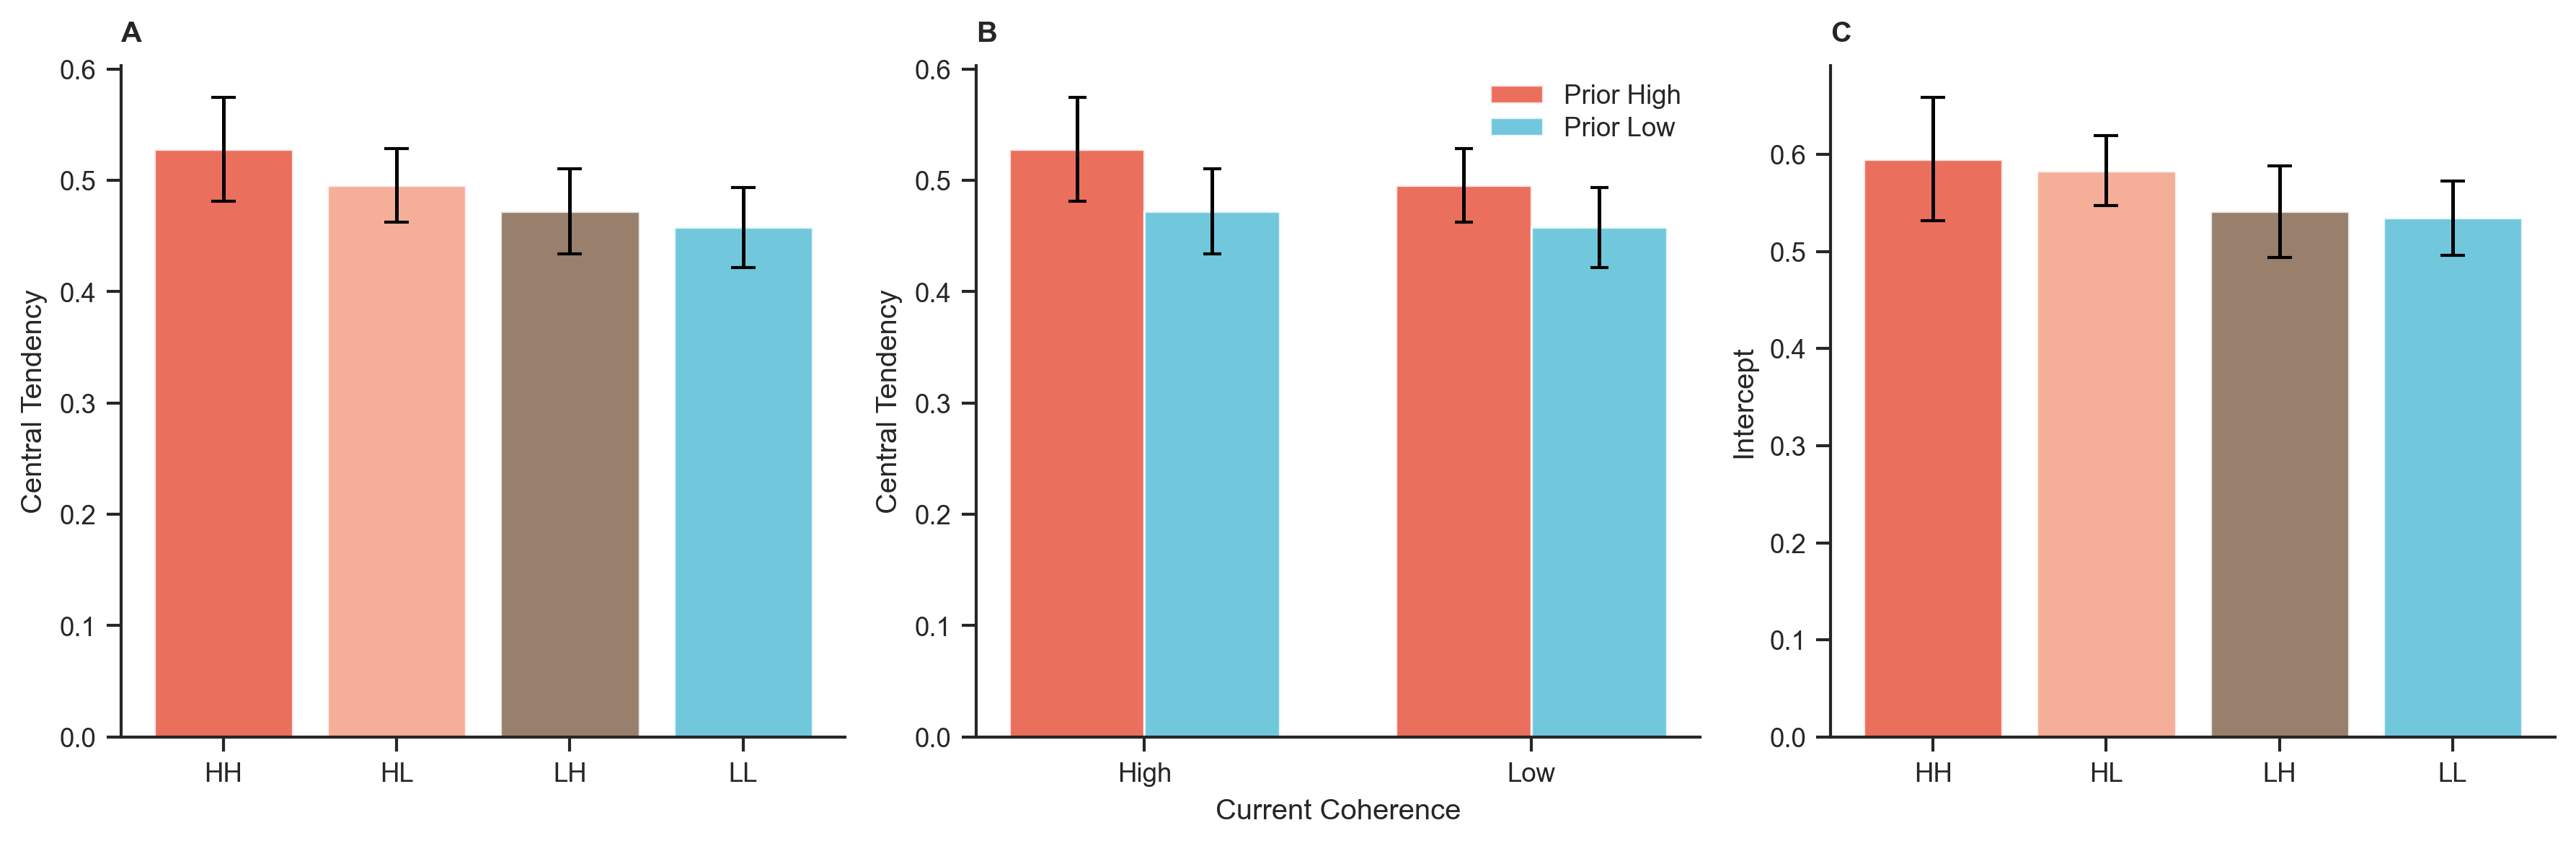

In [4]:
cti1 = compute_cti(df1)
cti1['preCoh'] = cti1['TransitionType'].apply(lambda x: 'High' if x[0] == 'H' else 'Low')
cti1['curCoh'] = cti1['TransitionType'].apply(lambda x: 'High' if x[1] == 'H' else 'Low')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Panel A: CTI by transition type
ax = axes[0]
cti_mean = cti1.groupby('TransitionType')['CTI'].agg(['mean', 'sem']).reindex(TRANSITION_ORDER)
ax.bar(TRANSITION_ORDER, cti_mean['mean'], yerr=cti_mean['sem'], capsize=4,
       color=[COLORS[t] for t in TRANSITION_ORDER], alpha=0.8)
ax.set_ylabel('Central Tendency')
ax.set_title('A', loc='left', fontweight='bold')
despine(ax)

# Panel B: CTI by prior × current coherence
ax = axes[1]
cti_2x2 = cti1.groupby(['preCoh', 'curCoh'])['CTI'].agg(['mean', 'sem']).reset_index()
x = np.arange(2)
width = 0.35
for i, prior in enumerate(['High', 'Low']):
    prior_data = cti_2x2[cti_2x2['preCoh'] == prior].set_index('curCoh').reindex(['High', 'Low'])
    color = COLORS['high'] if prior == 'High' else COLORS['low']
    ax.bar(x + width * (i - 0.5), prior_data['mean'], width, yerr=prior_data['sem'],
           label=f'Prior {prior}', capsize=3, color=color, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['High', 'Low'])
ax.set_xlabel('Current Coherence')
ax.set_ylabel('Central Tendency')
ax.legend(frameon=False)
ax.set_title('B', loc='left', fontweight='bold')
despine(ax)

# Panel C: Intercepts
ax = axes[2]
int_mean = cti1.groupby('TransitionType')['Intercept'].agg(['mean', 'sem']).reindex(TRANSITION_ORDER)
ax.bar(TRANSITION_ORDER, int_mean['mean'], yerr=int_mean['sem'], capsize=4,
       color=[COLORS[t] for t in TRANSITION_ORDER], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Intercept')
ax.set_title('C', loc='left', fontweight='bold')
despine(ax)

plt.tight_layout()
plt.savefig(fig_path / 'figS1_cti_exp1.png', dpi=300, bbox_inches='tight')
plt.savefig(fig_path / 'figS1_cti_exp1.pdf', bbox_inches='tight')
plt.show()

## Figure S2: Serial Dependence - Experiment 1

Matching Figure S1 structure: (A) SDI by transition type, (B) SDI by prior × current coherence, (C) General bias (intercepts)

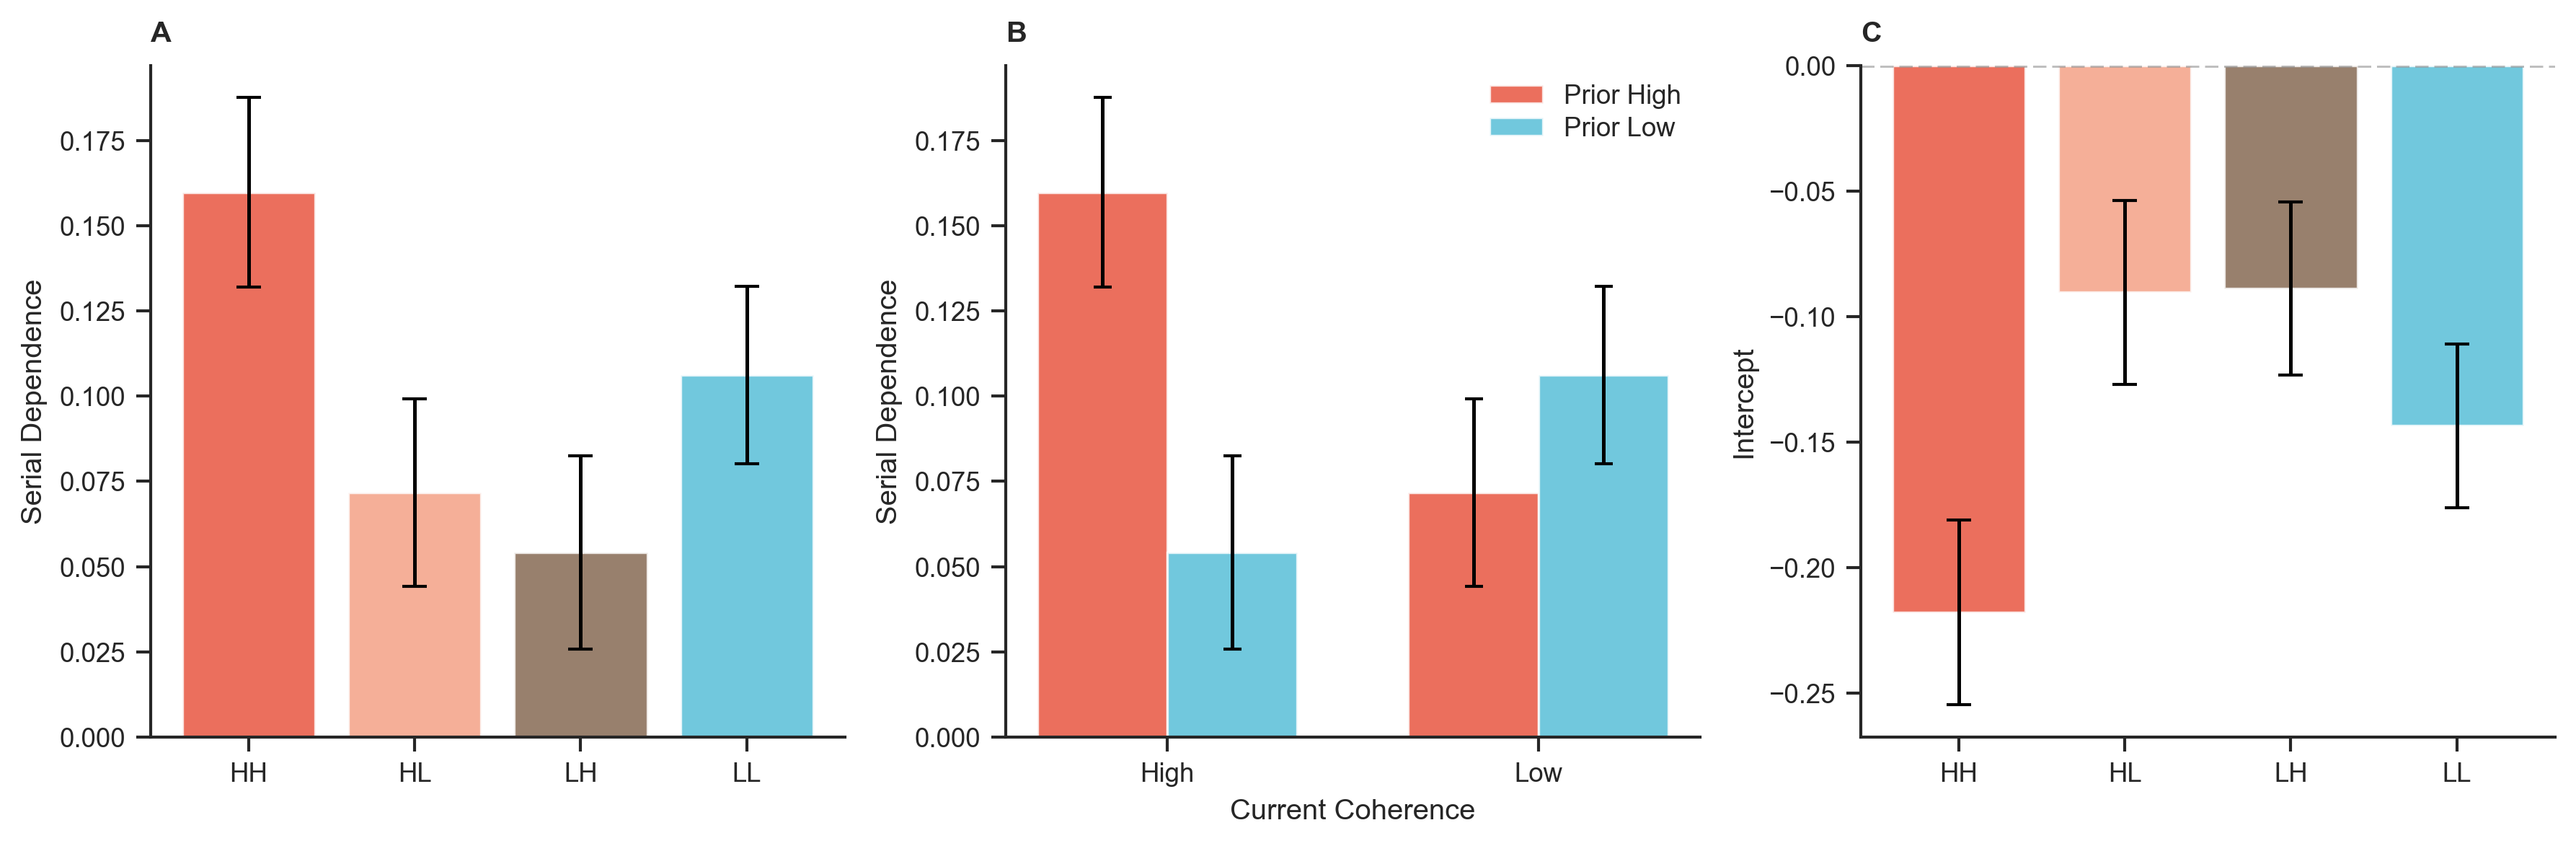

In [5]:
# Figure S2: Serial Dependence - Experiment 1 (matching S1 structure)
sdi1 = compute_sdi(df1)
sdi1['preCoh'] = sdi1['TransitionType'].apply(lambda x: 'High' if x[0] == 'H' else 'Low')
sdi1['curCoh'] = sdi1['TransitionType'].apply(lambda x: 'High' if x[1] == 'H' else 'Low')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Panel A: SDI by transition type
ax = axes[0]
sdi_mean = sdi1.groupby('TransitionType')['SDI'].agg(['mean', 'sem']).reindex(TRANSITION_ORDER)
ax.bar(TRANSITION_ORDER, sdi_mean['mean'], yerr=sdi_mean['sem'], capsize=4,
       color=[COLORS[t] for t in TRANSITION_ORDER], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Serial Dependence')
ax.set_title('A', loc='left', fontweight='bold')
despine(ax)

# Panel B: SDI by prior × current coherence
ax = axes[1]
sdi_2x2 = sdi1.groupby(['preCoh', 'curCoh'])['SDI'].agg(['mean', 'sem']).reset_index()
x = np.arange(2)
width = 0.35
for i, prior in enumerate(['High', 'Low']):
    prior_data = sdi_2x2[sdi_2x2['preCoh'] == prior].set_index('curCoh').reindex(['High', 'Low'])
    color = COLORS['high'] if prior == 'High' else COLORS['low']
    ax.bar(x + width * (i - 0.5), prior_data['mean'], width, yerr=prior_data['sem'],
           label=f'Prior {prior}', capsize=3, color=color, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['High', 'Low'])
ax.set_xlabel('Current Coherence')
ax.set_ylabel('Serial Dependence')
ax.legend(frameon=False)
ax.set_title('B', loc='left', fontweight='bold')
despine(ax)

# Panel C: Intercepts (General Bias)
ax = axes[2]
int_mean = sdi1.groupby('TransitionType')['Intercept'].agg(['mean', 'sem']).reindex(TRANSITION_ORDER)
ax.bar(TRANSITION_ORDER, int_mean['mean'], yerr=int_mean['sem'], capsize=4,
       color=[COLORS[t] for t in TRANSITION_ORDER], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Intercept')
ax.set_title('C', loc='left', fontweight='bold')
despine(ax)

plt.tight_layout()
plt.savefig(fig_path / 'figS2_sdi_exp1.png', dpi=300, bbox_inches='tight')
plt.savefig(fig_path / 'figS2_sdi_exp1.pdf', bbox_inches='tight')
plt.show()

## Figure S3: Central Tendency - Experiment 2

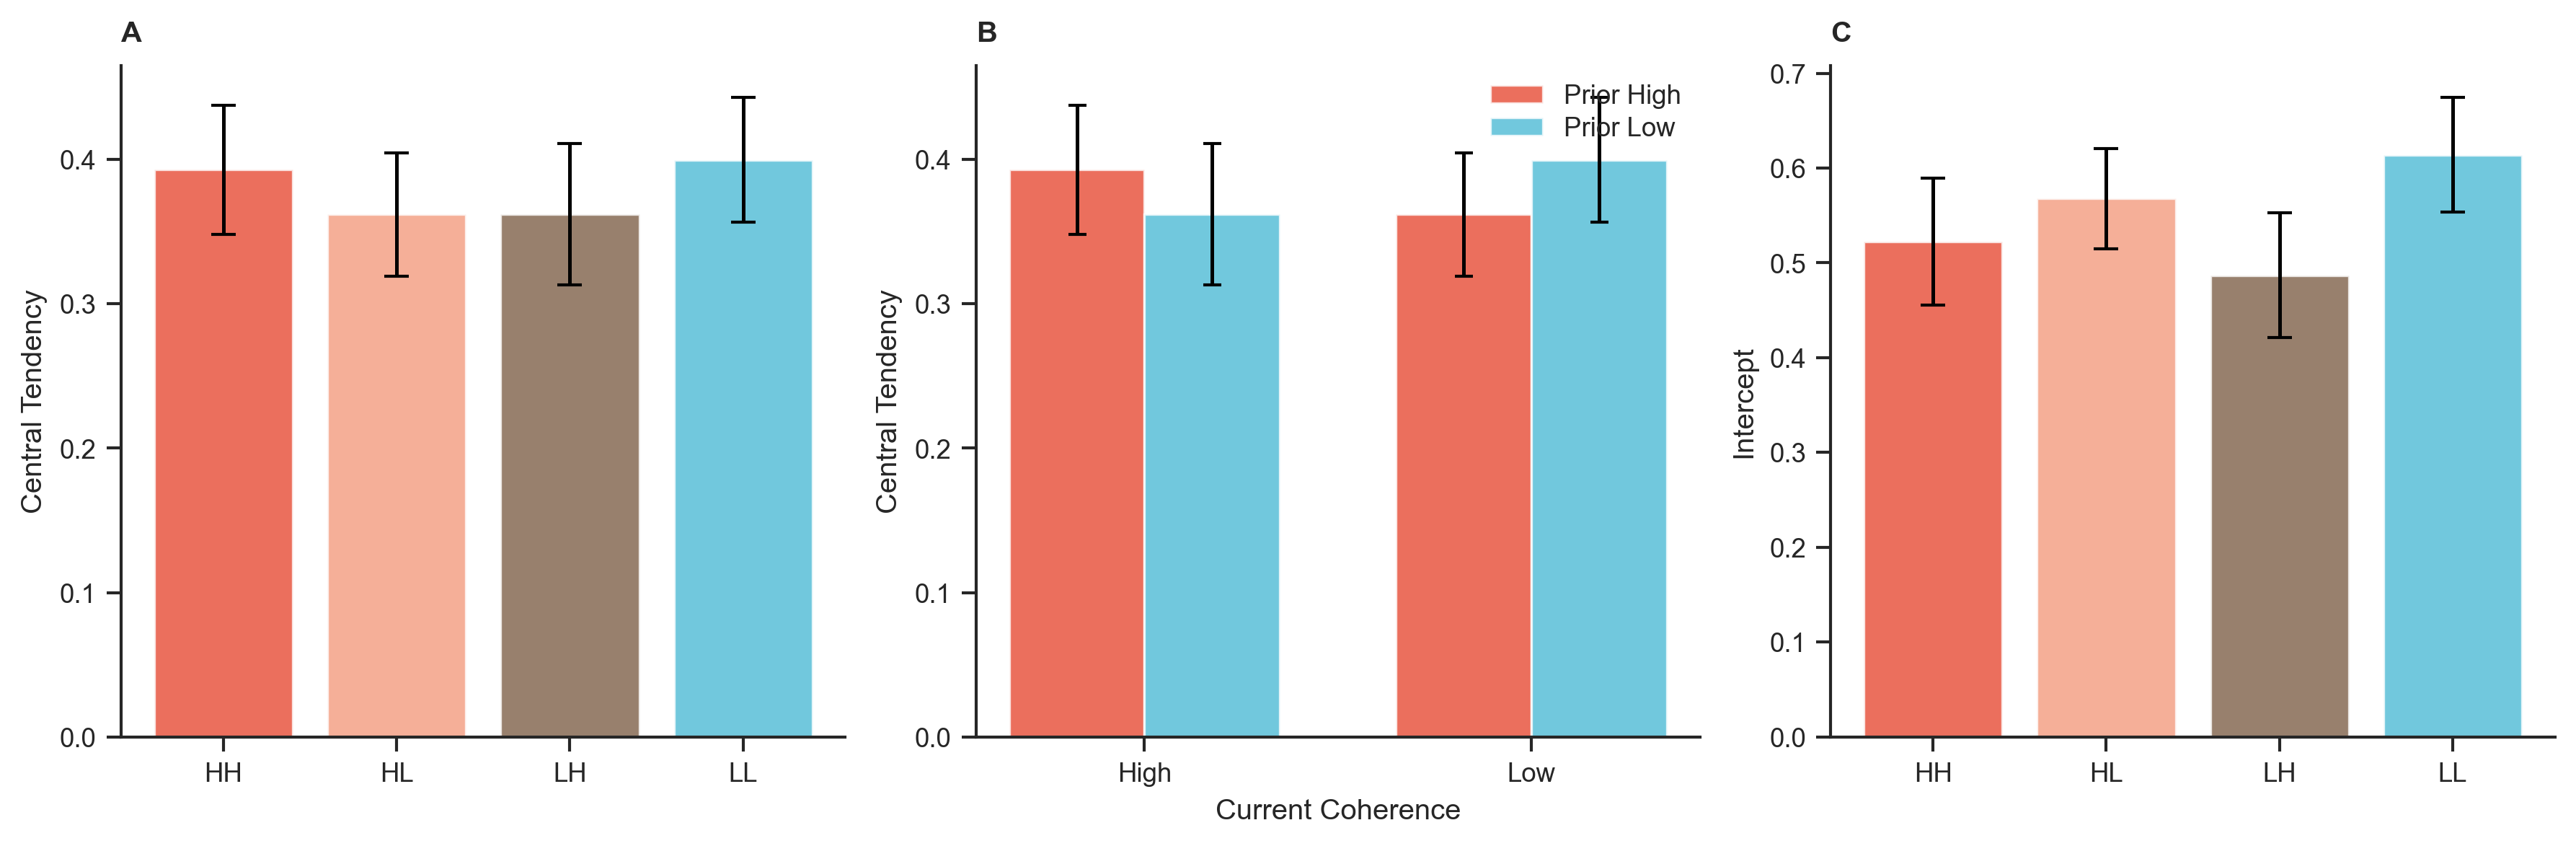

In [6]:
# Figure S3: Central Tendency - Experiment 2 (matching S1 structure with 3 panels)
cti2 = compute_cti(df2)
cti2['preCoh'] = cti2['TransitionType'].apply(lambda x: 'High' if x[0] == 'H' else 'Low')
cti2['curCoh'] = cti2['TransitionType'].apply(lambda x: 'High' if x[1] == 'H' else 'Low')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Panel A: CTI by transition type
ax = axes[0]
cti_mean = cti2.groupby('TransitionType')['CTI'].agg(['mean', 'sem']).reindex(TRANSITION_ORDER)
ax.bar(TRANSITION_ORDER, cti_mean['mean'], yerr=cti_mean['sem'], capsize=4,
       color=[COLORS[t] for t in TRANSITION_ORDER], alpha=0.8)
ax.set_ylabel('Central Tendency')
ax.set_title('A', loc='left', fontweight='bold')
despine(ax)

# Panel B: CTI by prior × current coherence
ax = axes[1]
cti_2x2 = cti2.groupby(['preCoh', 'curCoh'])['CTI'].agg(['mean', 'sem']).reset_index()
x = np.arange(2)
width = 0.35
for i, prior in enumerate(['High', 'Low']):
    prior_data = cti_2x2[cti_2x2['preCoh'] == prior].set_index('curCoh').reindex(['High', 'Low'])
    color = COLORS['high'] if prior == 'High' else COLORS['low']
    ax.bar(x + width * (i - 0.5), prior_data['mean'], width, yerr=prior_data['sem'],
           label=f'Prior {prior}', capsize=3, color=color, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['High', 'Low'])
ax.set_xlabel('Current Coherence')
ax.set_ylabel('Central Tendency')
ax.legend(frameon=False)
ax.set_title('B', loc='left', fontweight='bold')
despine(ax)

# Panel C: Intercepts (General Bias)
ax = axes[2]
int_mean = cti2.groupby('TransitionType')['Intercept'].agg(['mean', 'sem']).reindex(TRANSITION_ORDER)
ax.bar(TRANSITION_ORDER, int_mean['mean'], yerr=int_mean['sem'], capsize=4,
       color=[COLORS[t] for t in TRANSITION_ORDER], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Intercept')
ax.set_title('C', loc='left', fontweight='bold')
despine(ax)

plt.tight_layout()
plt.savefig(fig_path / 'figS3_cti_exp2.png', dpi=300, bbox_inches='tight')
plt.savefig(fig_path / 'figS3_cti_exp2.pdf', bbox_inches='tight')
plt.show()

## Figure S4: Serial Dependence - Experiment 2

Matching Figure S3 structure: (A) SDI by transition type, (B) SDI by prior × current coherence, (C) General bias (intercepts)

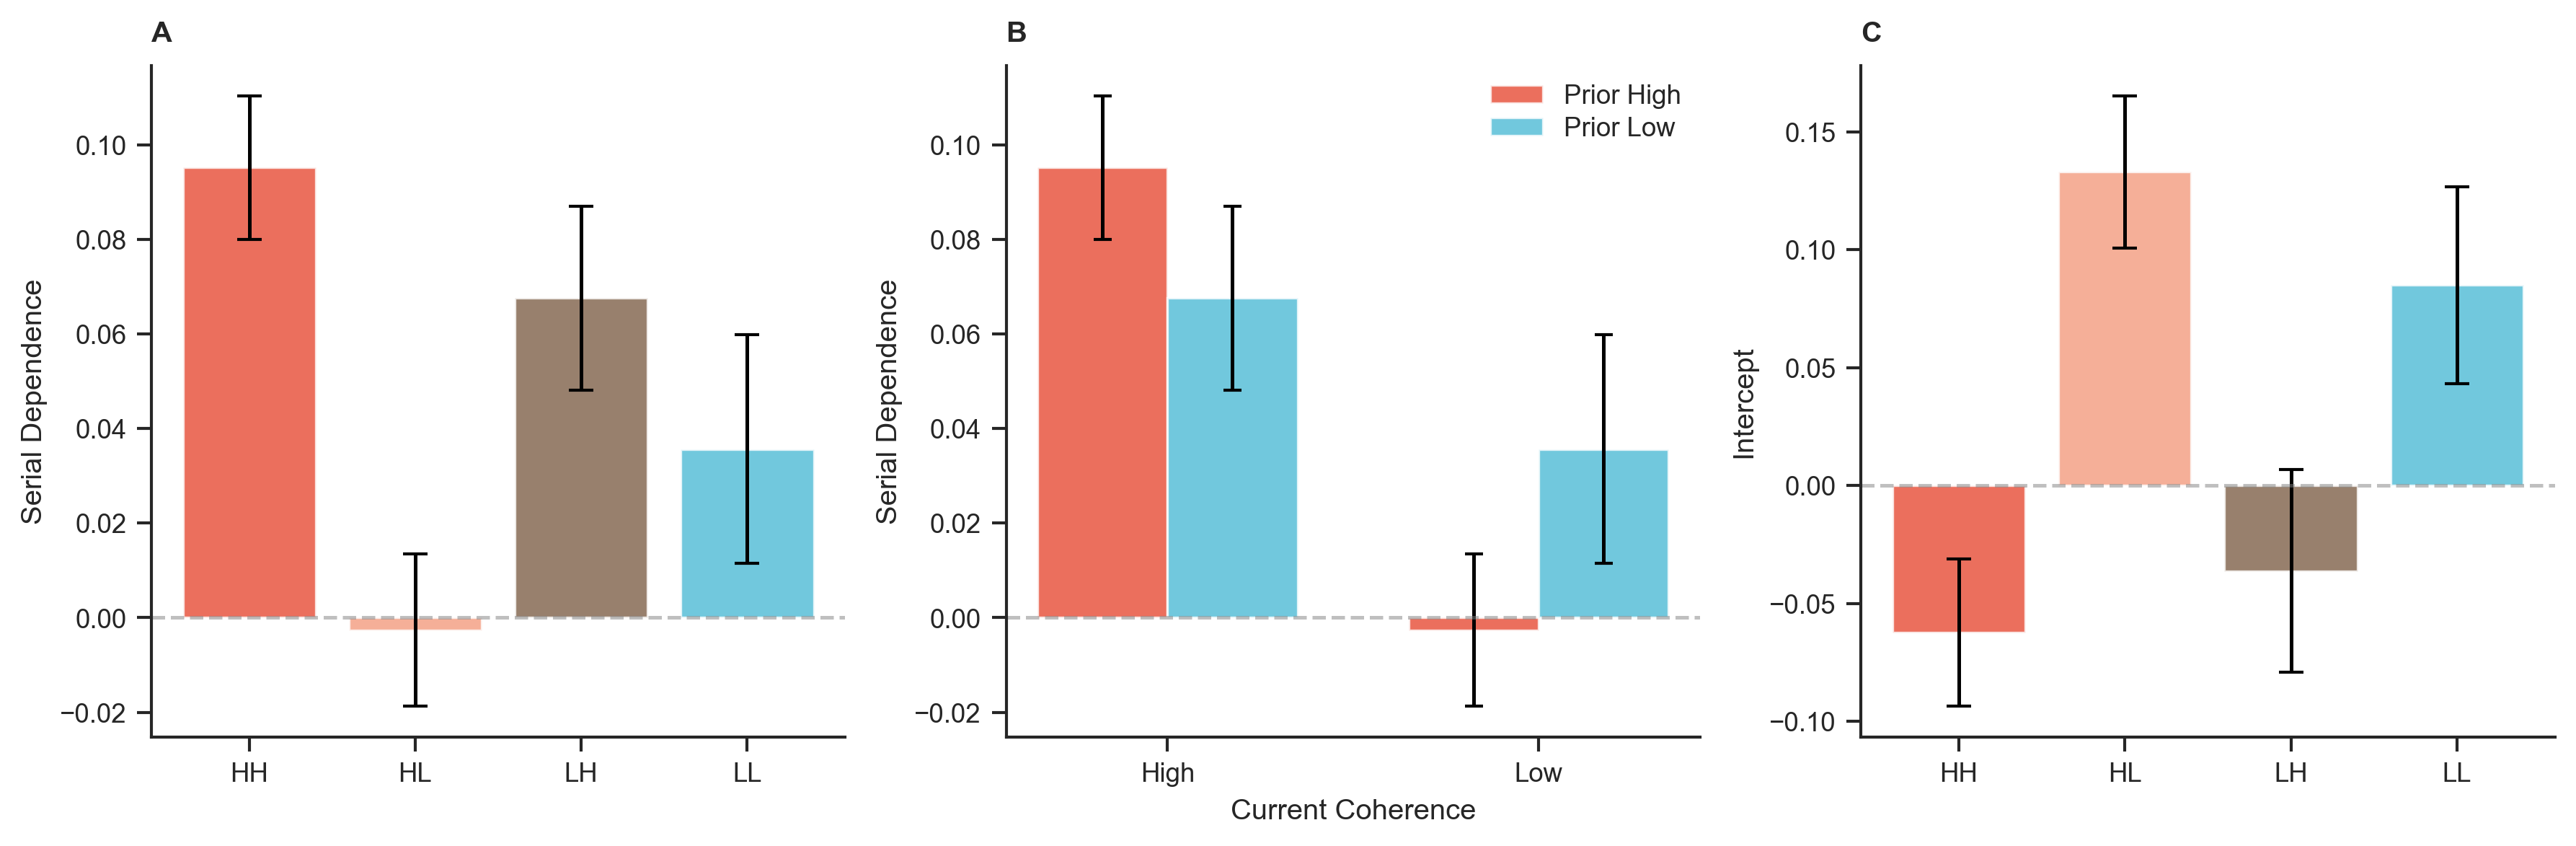

In [7]:
# Figure S4: Serial Dependence - Experiment 2 (matching S3 structure)
sdi2 = compute_sdi(df2)
sdi2['preCoh'] = sdi2['TransitionType'].apply(lambda x: 'High' if x[0] == 'H' else 'Low')
sdi2['curCoh'] = sdi2['TransitionType'].apply(lambda x: 'High' if x[1] == 'H' else 'Low')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Panel A: SDI by transition type
ax = axes[0]
sdi_mean = sdi2.groupby('TransitionType')['SDI'].agg(['mean', 'sem']).reindex(TRANSITION_ORDER)
ax.bar(TRANSITION_ORDER, sdi_mean['mean'], yerr=sdi_mean['sem'], capsize=4,
       color=[COLORS[t] for t in TRANSITION_ORDER], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Serial Dependence')
ax.set_title('A', loc='left', fontweight='bold')
despine(ax)

# Panel B: SDI by prior × current coherence
ax = axes[1]
sdi_2x2 = sdi2.groupby(['preCoh', 'curCoh'])['SDI'].agg(['mean', 'sem']).reset_index()
x = np.arange(2)
width = 0.35
for i, prior in enumerate(['High', 'Low']):
    prior_data = sdi_2x2[sdi_2x2['preCoh'] == prior].set_index('curCoh').reindex(['High', 'Low'])
    color = COLORS['high'] if prior == 'High' else COLORS['low']
    ax.bar(x + width * (i - 0.5), prior_data['mean'], width, yerr=prior_data['sem'],
           label=f'Prior {prior}', capsize=3, color=color, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['High', 'Low'])
ax.set_xlabel('Current Coherence')
ax.set_ylabel('Serial Dependence')
ax.legend(frameon=False)
ax.set_title('B', loc='left', fontweight='bold')
despine(ax)

# Panel C: Intercepts (General Bias)
ax = axes[2]
int_mean = sdi2.groupby('TransitionType')['Intercept'].agg(['mean', 'sem']).reindex(TRANSITION_ORDER)
ax.bar(TRANSITION_ORDER, int_mean['mean'], yerr=int_mean['sem'], capsize=4,
       color=[COLORS[t] for t in TRANSITION_ORDER], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Intercept')
ax.set_title('C', loc='left', fontweight='bold')
despine(ax)

plt.tight_layout()
plt.savefig(fig_path / 'figS4_sdi_exp2.png', dpi=300, bbox_inches='tight')
plt.savefig(fig_path / 'figS4_sdi_exp2.pdf', bbox_inches='tight')
plt.show()

## Figure S5: N-back Serial Dependence by Current Coherence (Bar Plot)

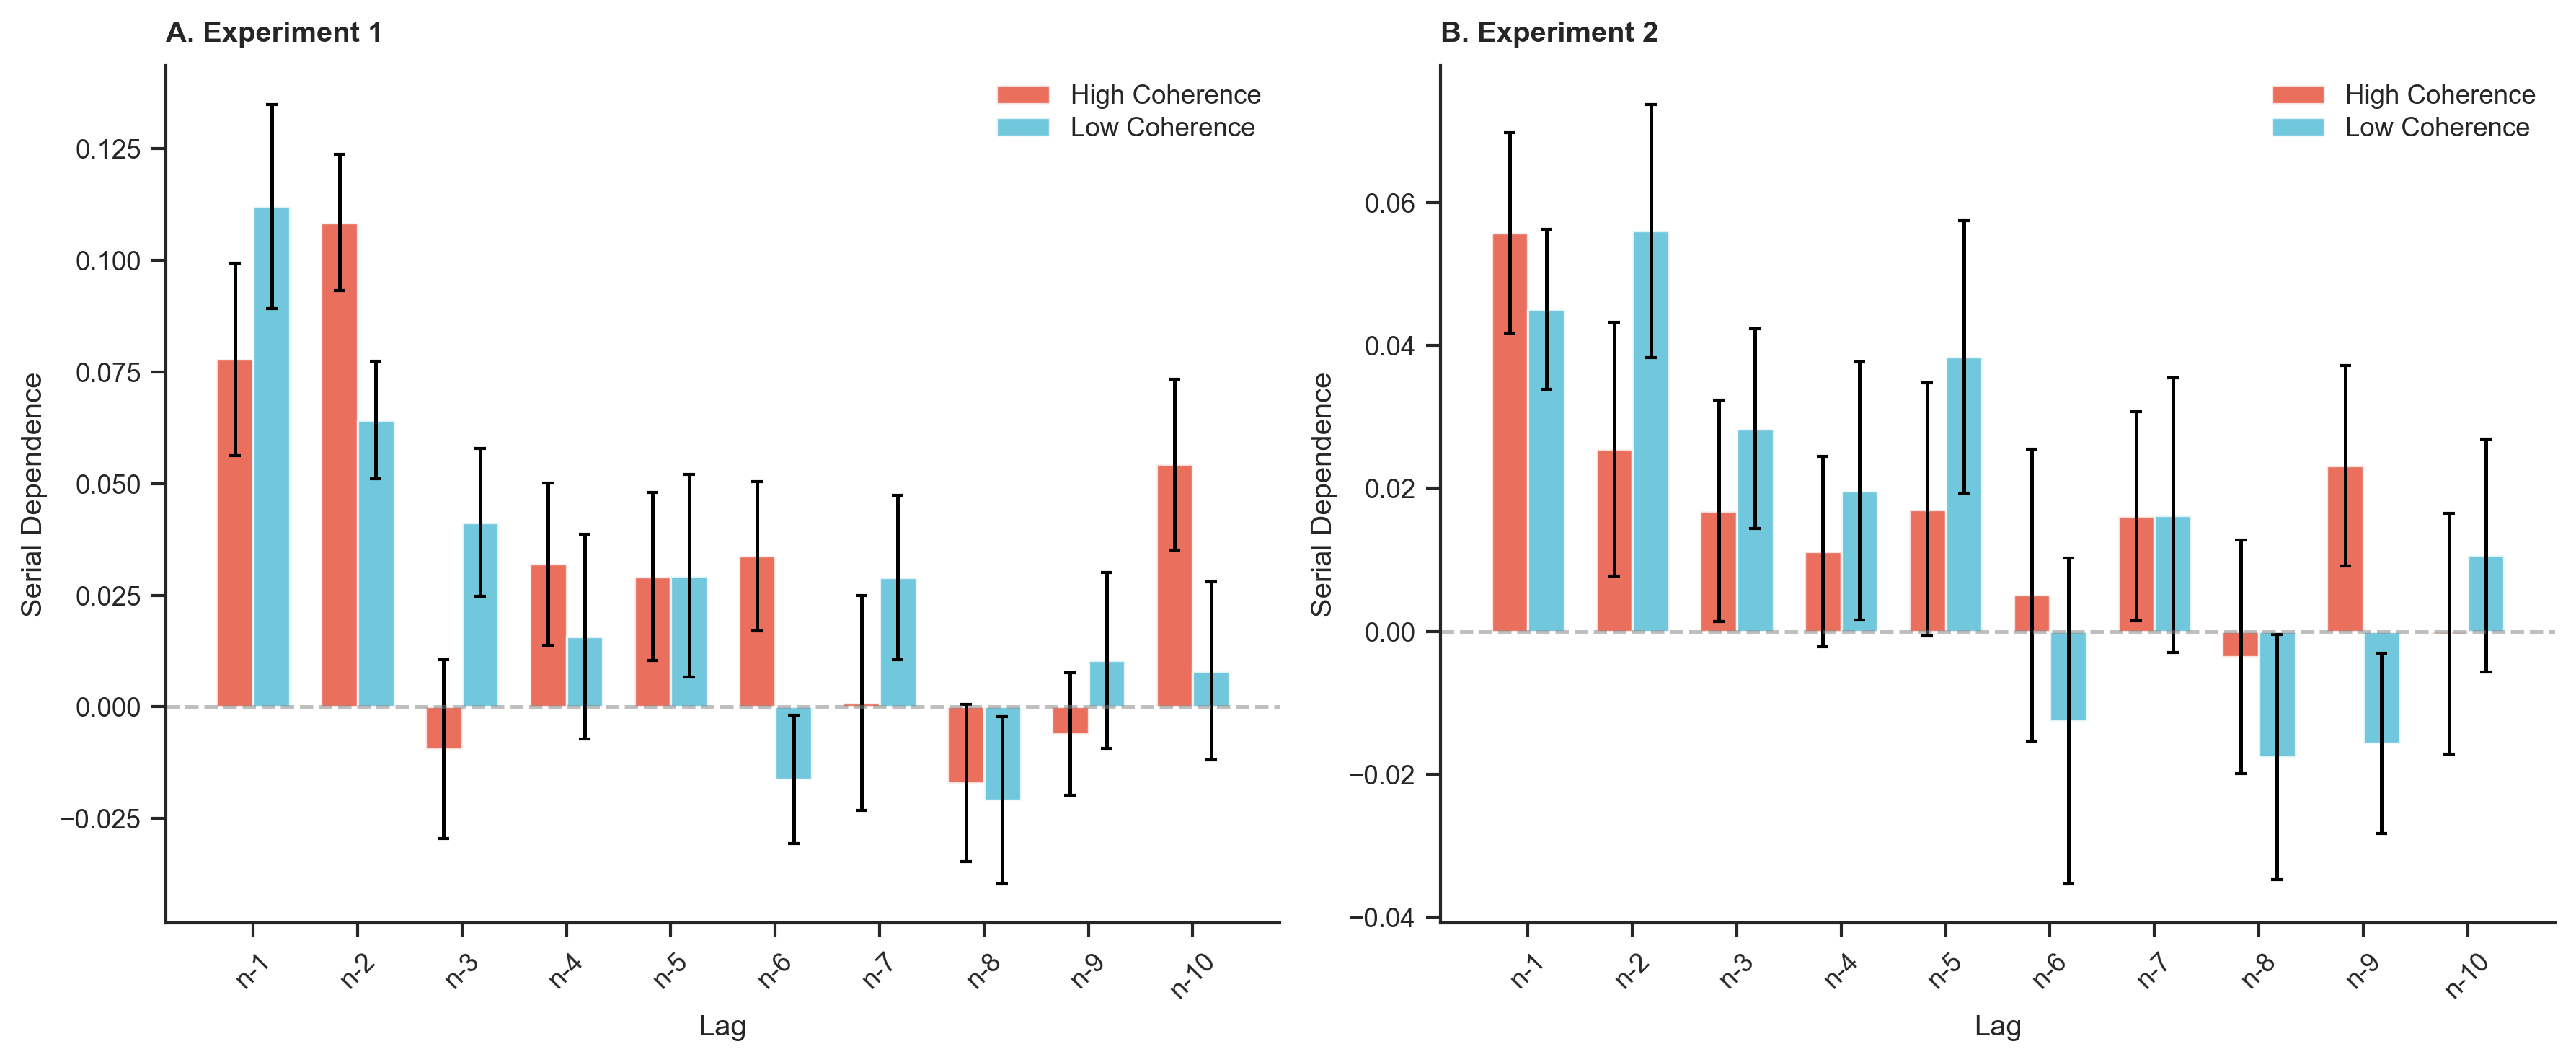

In [8]:
def compute_nback_sdi_by_coherence(df, max_back=10):
    """
    Compute SDI for n-back trials by PREVIOUS coherence at each lag.
    Following the approach in 2_Appendix.ipynb:
    - For each lag n, use preCoherence{n}back to determine high/low coherence
    - High = High coherence (0.7)
    - Low = Low coherence (0.3)
    """
    dur_cols = [f'preDur{i}back' for i in range(1, max_back + 1)]
    coh_cols = [f'preCoherence{i}back' for i in range(1, max_back + 1)]
    
    results = []
    for sub in df['subID'].unique():
        sub_df = df[df['subID'] == sub]
        
        for n, (dur_col, coh_col) in enumerate(zip(dur_cols, coh_cols), start=1):
            if dur_col not in sub_df.columns or coh_col not in sub_df.columns:
                continue
            
            for coh_val, coh_label in [(0.3, 'Low'), (0.7, 'High')]:  # High/Low = coherence level
                data = sub_df[sub_df[coh_col] == coh_val].dropna(subset=[dur_col, 'curBias'])
                if len(data) > 10:
                    slope, _, _, p, _ = stats.linregress(data[dur_col], data['curBias'])
                    results.append({
                        'subID': sub, 
                        'Coherence': coh_label,  # Coherence level (High/Low)
                        'nback': n, 
                        'SDI': slope, 
                        'p': p
                    })
    return pd.DataFrame(results)

nback1 = compute_nback_sdi_by_coherence(df1, max_back=10)
nback2 = compute_nback_sdi_by_coherence(df2, max_back=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(1, 11)
width = 0.35
lag_labels = [f'n-{i}' for i in range(1, 11)]

# Exp1
ax = axes[0]
for i, (unc, color) in enumerate([('High', COLORS['high']), ('Low', COLORS['low'])]):
    unc_data = nback1[nback1['Coherence'] == unc].groupby('nback')['SDI'].agg(['mean', 'sem'])
    offset = width * (i - 0.5)
    ax.bar(x + offset, unc_data['mean'], width, yerr=unc_data['sem'], capsize=2,
           label=f'{unc} Coherence', color=color, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(lag_labels, rotation=45)
ax.set_xlabel('Lag')
ax.set_ylabel('Serial Dependence')
ax.set_title('A. Experiment 1', loc='left', fontweight='bold')
ax.legend(frameon=False)
despine(ax)

# Exp2
ax = axes[1]
for i, (unc, color) in enumerate([('High', COLORS['high']), ('Low', COLORS['low'])]):
    unc_data = nback2[nback2['Coherence'] == unc].groupby('nback')['SDI'].agg(['mean', 'sem'])
    offset = width * (i - 0.5)
    ax.bar(x + offset, unc_data['mean'], width, yerr=unc_data['sem'], capsize=2,
           label=f'{unc} Coherence', color=color, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(lag_labels, rotation=45)
ax.set_xlabel('Lag')
ax.set_ylabel('Serial Dependence')
ax.set_title('B. Experiment 2', loc='left', fontweight='bold')
ax.legend(frameon=False)
despine(ax)

plt.tight_layout()
plt.savefig(fig_path / 'figS5_10back_coherence.png', dpi=300, bbox_inches='tight')
plt.savefig(fig_path / 'figS5_10back_coherence.pdf', bbox_inches='tight')
plt.show()

## Figure S6: N-back Serial Dependence by Transition Type (Bar Plot)

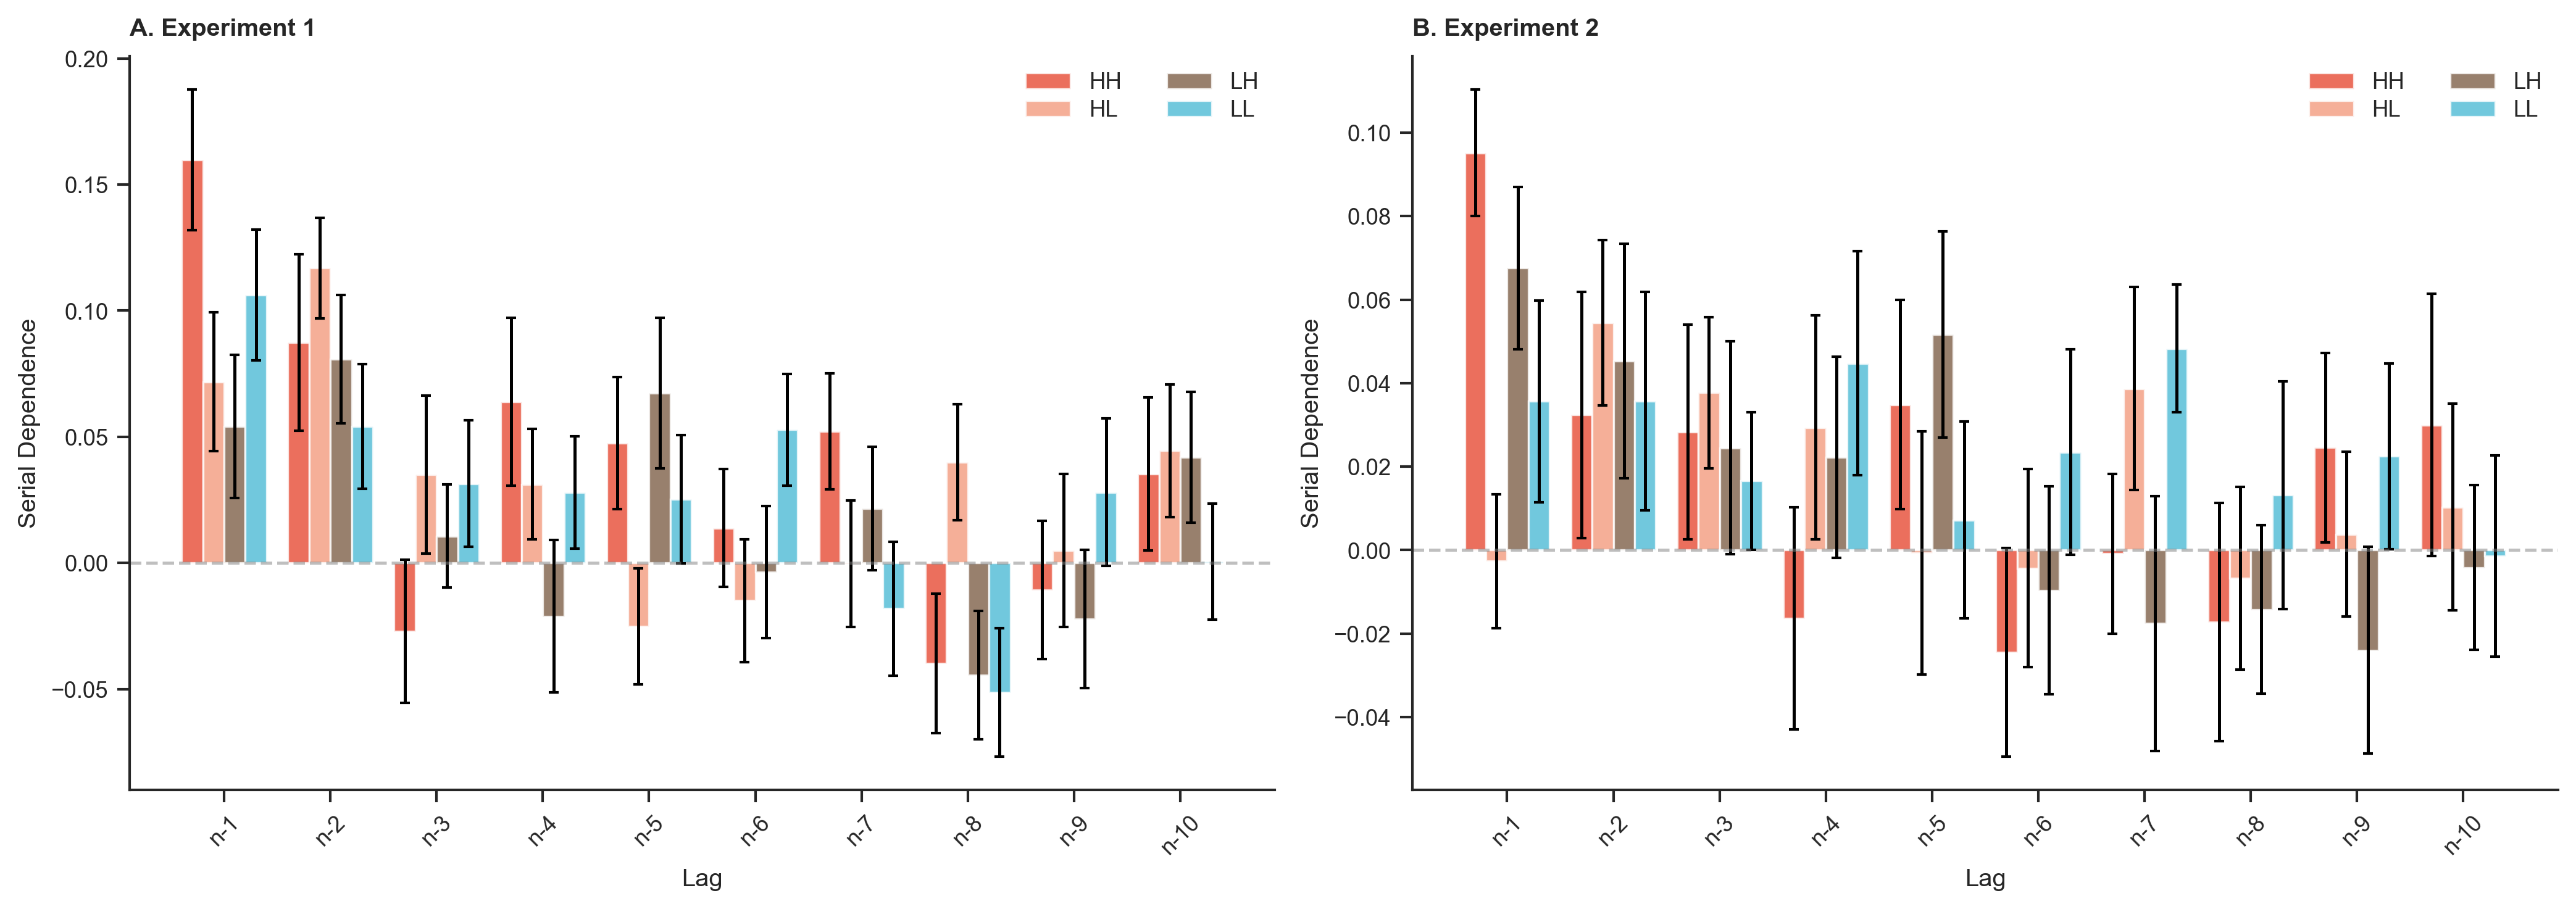

In [9]:
def compute_nback_sdi_by_transition(df, max_back=10):
    """Compute SDI for n-back trials by transition type."""
    dur_cols = [f'preDur{i}back' for i in range(1, max_back + 1)]
    
    results = []
    for sub in df['subID'].unique():
        for tt in TRANSITION_ORDER:
            sub_df = df[(df['subID'] == sub) & (df['TransitionType'] == tt)]
            
            for n, dur_col in enumerate(dur_cols, start=1):
                if dur_col not in sub_df.columns:
                    continue
                valid = sub_df.dropna(subset=[dur_col, 'curBias'])
                if len(valid) > 5:
                    slope, _, _, p, _ = stats.linregress(valid[dur_col], valid['curBias'])
                    results.append({
                        'subID': sub, 
                        'TransitionType': tt, 
                        'nback': n,
                        'SDI': slope, 
                        'p': p
                    })
    return pd.DataFrame(results)

nback1_tt = compute_nback_sdi_by_transition(df1, max_back=10)
nback2_tt = compute_nback_sdi_by_transition(df2, max_back=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(1, 11)
width = 0.2
lag_labels = [f'n-{i}' for i in range(1, 11)]

# Exp1
ax = axes[0]
for i, tt in enumerate(TRANSITION_ORDER):
    tt_data = nback1_tt[nback1_tt['TransitionType'] == tt].groupby('nback')['SDI'].agg(['mean', 'sem'])
    offset = width * (i - 1.5)
    ax.bar(x + offset, tt_data['mean'], width, yerr=tt_data['sem'], capsize=2,
           label=tt, color=COLORS[tt], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(lag_labels, rotation=45)
ax.set_xlabel('Lag')
ax.set_ylabel('Serial Dependence')
ax.set_title('A. Experiment 1', loc='left', fontweight='bold')
ax.legend(frameon=False, ncol=2)
despine(ax)

# Exp2
ax = axes[1]
for i, tt in enumerate(TRANSITION_ORDER):
    tt_data = nback2_tt[nback2_tt['TransitionType'] == tt].groupby('nback')['SDI'].agg(['mean', 'sem'])
    offset = width * (i - 1.5)
    ax.bar(x + offset, tt_data['mean'], width, yerr=tt_data['sem'], capsize=2,
           label=tt, color=COLORS[tt], alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(lag_labels, rotation=45)
ax.set_xlabel('Lag')
ax.set_ylabel('Serial Dependence')
ax.set_title('B. Experiment 2', loc='left', fontweight='bold')
ax.legend(frameon=False, ncol=2)
despine(ax)

plt.tight_layout()
plt.savefig(fig_path / 'figS6_10back_transition.png', dpi=300, bbox_inches='tight')
plt.savefig(fig_path / 'figS6_10back_transition.pdf', bbox_inches='tight')
plt.show()

## Figure S7: Distribution of Reproduction Bias

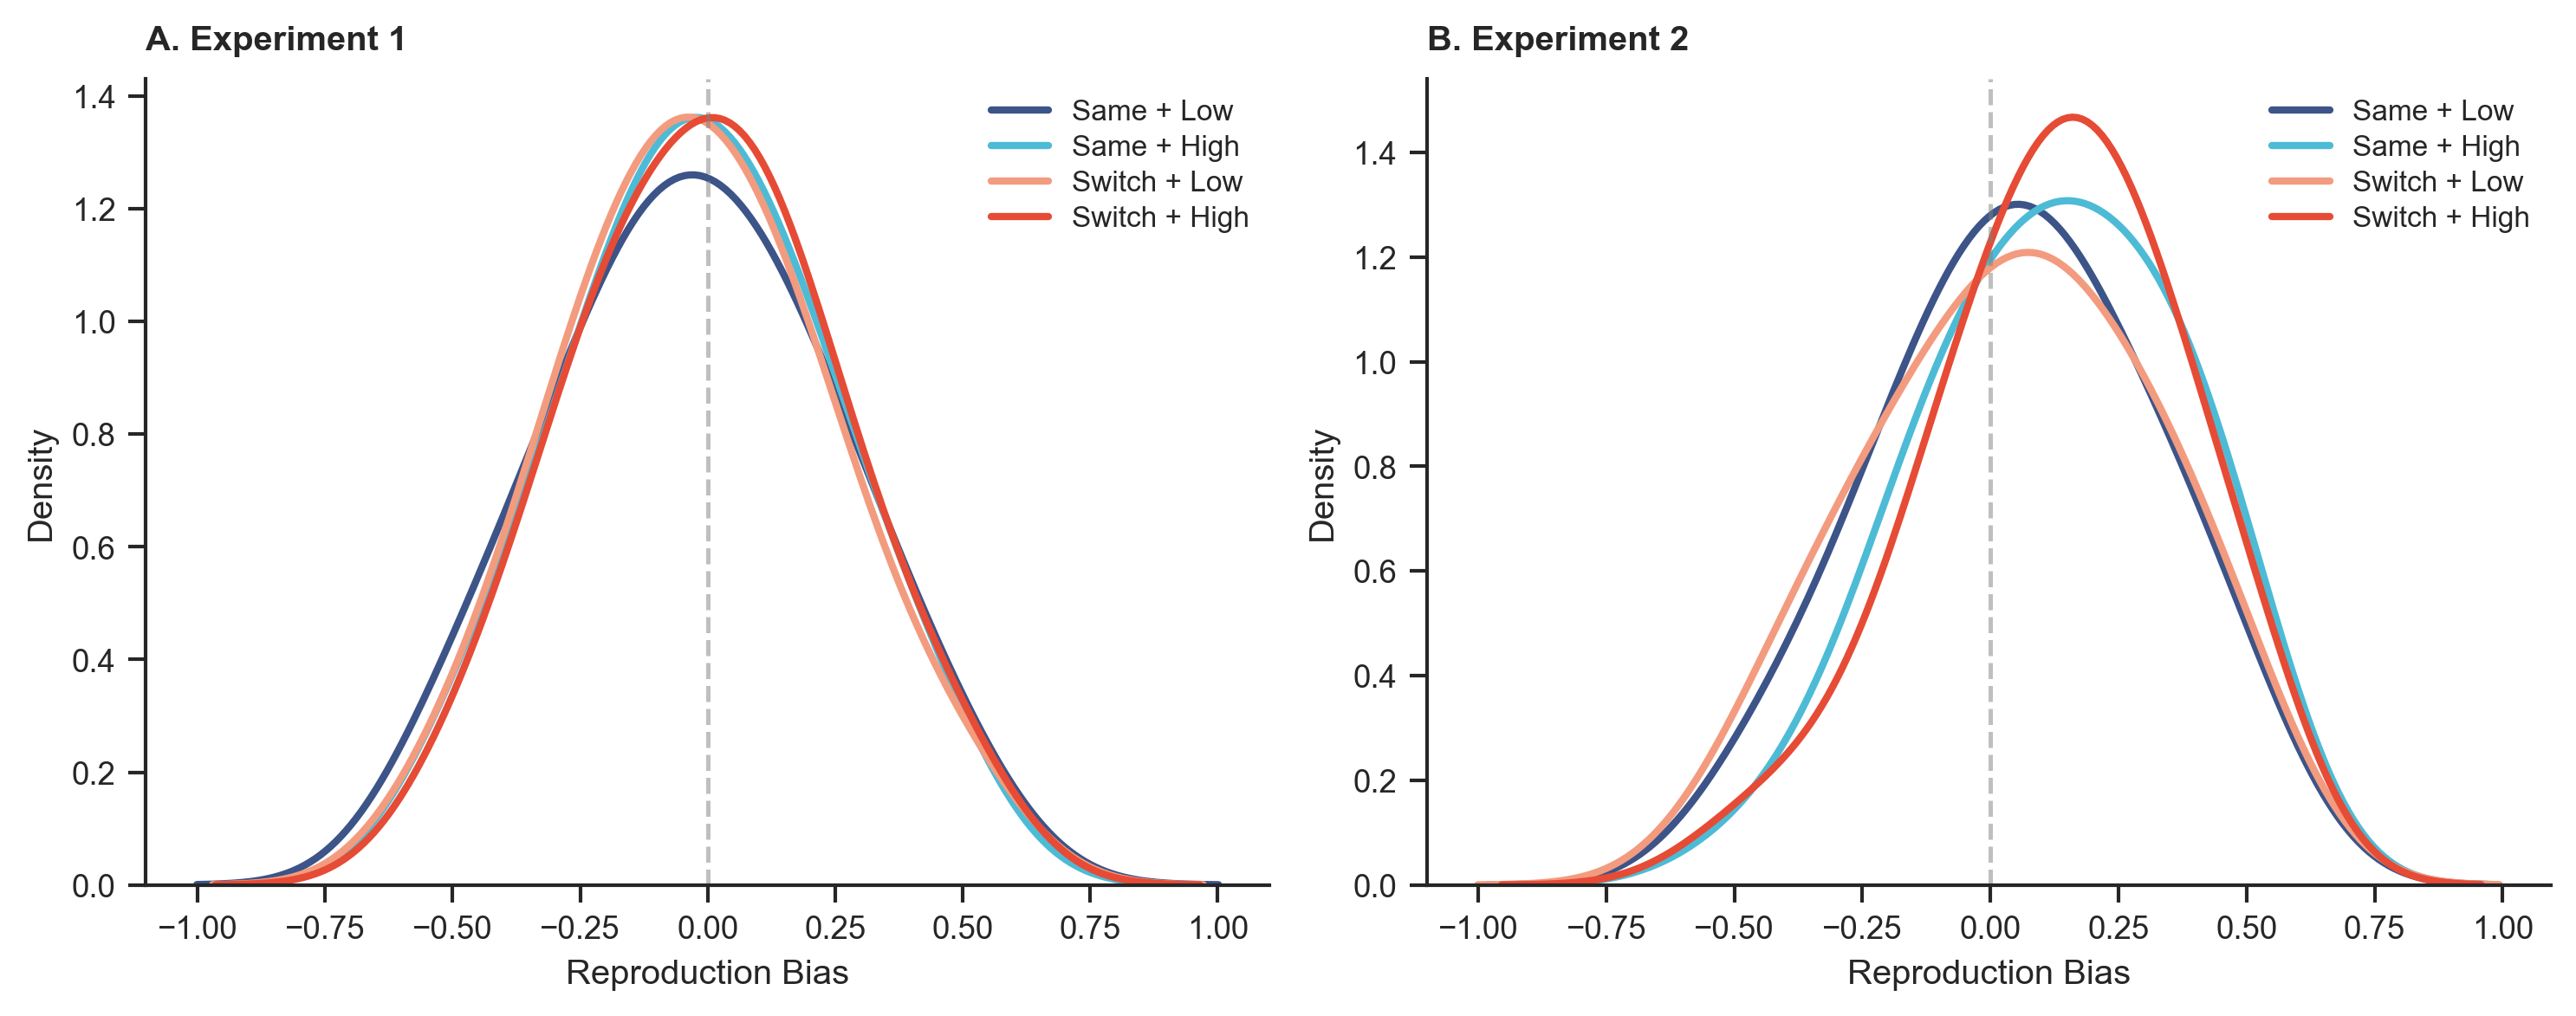

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Exp1
ax = axes[0]
df1['Gating'] = df1['TransitionType'].map({'HH': 'Same', 'LL': 'Same', 'HL': 'Switch', 'LH': 'Switch'})
df1['Coherence'] = df1['curCoherence'].map({0.3: 'Low', 0.7: 'High'})

cond_colors = {
    'Same + Low': COLORS['same'],
    'Same + High': COLORS['low'],
    'Switch + Low': COLORS['switch'],
    'Switch + High': COLORS['high']
}

for gating in ['Same', 'Switch']:
    for unc in ['Low', 'High']:
        cond = f'{gating} + {unc}'
        data = df1[(df1['Gating'] == gating) & (df1['Coherence'] == unc)]['curBias']
        sns.kdeplot(data, ax=ax, label=cond, color=cond_colors[cond], lw=2, bw_adjust=2)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Reproduction Bias')
ax.set_ylabel('Density')
ax.set_title('A. Experiment 1', loc='left', fontweight='bold')
ax.legend(fontsize=8, frameon=False)
despine(ax)

# Exp2
ax = axes[1]
df2['Gating'] = df2['TransitionType'].map({'HH': 'Same', 'LL': 'Same', 'HL': 'Switch', 'LH': 'Switch'})
df2['Coherence'] = df2['curCoherence'].map({0.3: 'Low', 0.7: 'High'})

for gating in ['Same', 'Switch']:
    for unc in ['Low', 'High']:
        cond = f'{gating} + {unc}'
        data = df2[(df2['Gating'] == gating) & (df2['Coherence'] == unc)]['curBias']
        sns.kdeplot(data, ax=ax, label=cond, color=cond_colors[cond], lw=2, bw_adjust=2)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Reproduction Bias')
ax.set_ylabel('Density')
ax.set_title('B. Experiment 2', loc='left', fontweight='bold')
ax.legend(fontsize=8, frameon=False)
despine(ax)

plt.tight_layout()
plt.savefig(fig_path / 'figS7_bias_dist.png', dpi=300, bbox_inches='tight')
plt.savefig(fig_path / 'figS7_bias_dist.pdf', bbox_inches='tight')
plt.show()

## Summary

Generated figures:
- `figS1_cti_exp1.png` - Central Tendency Analysis, Experiment 1
- `figS2_bias_exp1.png` - General Bias of SD, Experiment 1
- `figS3_cti_exp2.png` - Central Tendency Analysis, Experiment 2
- `figS4_bias_exp2.png` - General Bias of SD, Experiment 2
- `figS5_10back_coherence.png` - N-back SD by Current Coherence (Bar)
- `figS6_10back_transition.png` - N-back SD by Transition Type (Bar)
- `figS7_bias_dist.png` - Distribution of Reproduction Bias